# Final Machine Learning Project: Customer Churn Classification

**Student:** Monepha Mitchell  
**Course:** ITAI 1371 – Machine Learning  
**Project Type:** Binary Classification  
**Target Variable:** Churn  

## Project Objective

The purpose of this project is to develop a machine-learning model that predicts whether a telecommunications customer will churn. Six classification models will be trained and compared using accuracy, precision, recall, F1-score, and ROC-AUC. An average ensemble and a Bayesian ensemble will also be created and evaluated.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Splitting the dataset
from sklearn.model_selection import train_test_split

# Prevent unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Use the same random number throughout the project
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Dataset URL from the midterm project
data_url = (
    "https://raw.githubusercontent.com/"
    "VedD376/ITAI-1371-ML-Dataset/main/"
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Load the dataset
df = pd.read_csv(data_url)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the first five rows
df.head()

Dataset loaded successfully.
Number of rows: 7043
Number of columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Display all column names
print("Dataset columns:")

for column in df.columns:
    print(column)

Dataset columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [4]:
# Count the customers in each target category
print("Churn counts:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


## Data Cleaning

Before training the models, the dataset must be checked for missing values, incorrect data types, duplicate rows, and columns that do not provide useful predictive information.

In [5]:
# Display the column names and data types
df.info()

# Check for standard missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check the current data type
print("TotalCharges data type:", df["TotalCharges"].dtype)

# Count blank spaces in TotalCharges
blank_total_charges = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Blank TotalCharges entries:", blank_total_charges)

TotalCharges data type: object
Blank TotalCharges entries: 11


In [7]:
# Convert TotalCharges from text to numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Count the missing values created during conversion
print(
    "Missing TotalCharges after conversion:",
    df["TotalCharges"].isnull().sum()
)

Missing TotalCharges after conversion: 11


In [8]:
# Display customers with missing TotalCharges
missing_total_charges = df[df["TotalCharges"].isnull()]

display(
    missing_total_charges[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn",
        ]
    ]
)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [9]:
# Replace missing TotalCharges with zero
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Confirm the correction
print("TotalCharges data type:", df["TotalCharges"].dtype)
print(
    "Missing TotalCharges values:",
    df["TotalCharges"].isnull().sum()
)


TotalCharges data type: float64
Missing TotalCharges values: 0


In [10]:
# Save customerID separately in case it is needed later
customer_ids = df["customerID"].copy()

# Remove customerID from the modeling dataset
df = df.drop(columns=["customerID"])

print("Updated dataset shape:", df.shape)
print("customerID" in df.columns)

Updated dataset shape: (7043, 20)
False


In [11]:
print("Cleaned dataset information:")
df.info()

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df.head()

Cleaned dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Feature Engineering

Feature engineering creates new variables from existing information that may help the machine-learning models recognize customer patterns. Two features will be created: `TenureGroup` and `NumberOfServices`.

In [12]:
# Check the minimum and maximum tenure values
print("Minimum tenure:", df["tenure"].min())
print("Maximum tenure:", df["tenure"].max())

Minimum tenure: 0
Maximum tenure: 72


In [13]:
# Define the boundaries for the tenure categories
tenure_bins = [-1, 12, 24, 48, 72]

# Give each tenure category a name
tenure_labels = [
    "New Customer",
    "Developing Customer",
    "Established Customer",
    "Long-Term Customer"
]

# Create the new TenureGroup column
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

# Display the first 10 results
df[["tenure", "TenureGroup"]].head(10)

,tenure,TenureGroup
0,1,New Customer
1,34,Established Customer
2,2,New Customer
3,45,Established Customer
4,2,New Customer
5,8,New Customer
6,22,Developing Customer
7,10,New Customer
8,28,Established Customer
9,62,Long-Term Customer


In [14]:
# Count customers in each tenure group
print("Customers in each tenure group:")
print(df["TenureGroup"].value_counts().sort_index())

# Check for missing categories
print(
    "\nMissing TenureGroup values:",
    df["TenureGroup"].isnull().sum()
)

Customers in each tenure group:
TenureGroup
New Customer            2186
Developing Customer     1024
Established Customer    1594
Long-Term Customer      2239
Name: count, dtype: int64

Missing TenureGroup values: 0


### Tenure Group Feature

I created the `TenureGroup` feature to organize customers according to how long they have remained with the company. Customer tenure may be related to churn because new customers may be less committed to the company, while long-term customers may have stronger relationships with its services.

In [15]:
# Identify the columns that represent customer services
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Display the possible values in each service column
for column in service_columns:
    print(column, df[column].unique())

PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']


In [16]:
# Count the number of active services used by each customer
df["NumberOfServices"] = (
    df[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

# Display the new feature
df[service_columns + ["NumberOfServices"]].head(10)

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,NumberOfServices
0,No,No phone service,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,Yes,No,No,No,3
2,Yes,No,Yes,Yes,No,No,No,No,3
3,No,No phone service,Yes,No,Yes,Yes,No,No,3
4,Yes,No,No,No,No,No,No,No,1
5,Yes,Yes,No,No,Yes,No,Yes,Yes,5
6,Yes,Yes,No,Yes,No,No,Yes,No,4
7,No,No phone service,Yes,No,No,No,No,No,1
8,Yes,Yes,No,No,Yes,Yes,Yes,Yes,6
9,Yes,No,Yes,Yes,No,No,No,No,3


In [17]:
print("Number of services summary:")
print(df["NumberOfServices"].describe())

print("\nCustomers grouped by number of services:")
print(
    df["NumberOfServices"]
    .value_counts()
    .sort_index()
)

Number of services summary:
count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: NumberOfServices, dtype: float64

Customers grouped by number of services:
NumberOfServices
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64


### Number of Services Feature

I created the `NumberOfServices` feature by counting the active services used by each customer. This combines information from multiple service columns into one numerical feature. Customers who use more services may be more connected to the company and could be less likely to churn.

In [18]:
# Confirm that both new features were created
print("Updated dataset shape:", df.shape)

print("\nNew feature data types:")
print(df[["TenureGroup", "NumberOfServices"]].dtypes)

print("\nMissing values in the new features:")
print(
    df[["TenureGroup", "NumberOfServices"]]
    .isnull()
    .sum()
)

# Display selected columns
df[
    [
        "tenure",
        "TenureGroup",
        "NumberOfServices",
        "Churn"
    ]
].head(10)

Updated dataset shape: (7043, 22)

New feature data types:
TenureGroup         category
NumberOfServices       int64
dtype: object

Missing values in the new features:
TenureGroup         0
NumberOfServices    0
dtype: int64


,tenure,TenureGroup,NumberOfServices,Churn
0,1,New Customer,1,No
1,34,Established Customer,3,No
2,2,New Customer,3,Yes
3,45,Established Customer,3,No
4,2,New Customer,1,Yes
5,8,New Customer,5,Yes
6,22,Developing Customer,4,No
7,10,New Customer,1,No
8,28,Established Customer,6,Yes
9,62,Long-Term Customer,3,No


## Preparing the Data for Modeling

The dataset will be separated into predictor variables and the target variable. The target variable, `Churn`, will be converted into numerical values. The data will then be divided into 70% training, 15% validation, and 15% testing sets.

In [20]:
# Separate the predictor variables from the target variable
X = df.drop(columns=["Churn"])

# Convert the target values into numbers
# No = 0 and Yes = 1
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nEncoded target values:")
print(y.value_counts())

Feature dataset shape: (7043, 21)
Target dataset shape: (7043,)

Encoded target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [21]:
# Confirm that no target values are missing
print("Missing target values:", y.isnull().sum())

# Display the first 10 original and encoded values
target_check = pd.DataFrame({
    "Original Churn": df["Churn"].head(10),
    "Encoded Churn": y.head(10)
})

target_check

Missing target values: 0


,Original Churn,Encoded Churn
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1
5,Yes,1
6,No,0
7,No,0
8,Yes,1
9,No,0


In [22]:
# First split:
# Reserve 15% of the full dataset for final testing

X_remaining, X_test, y_remaining, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Remaining data shape:", X_remaining.shape)
print("Test data shape:", X_test.shape)

Remaining data shape: (5986, 21)
Test data shape: (1057, 21)


In [23]:
# Calculate the percentage of the remaining data
# that must be assigned to validation

validation_size = 0.15 / 0.85

print("Validation fraction of remaining data:")
print(validation_size)

Validation fraction of remaining data:
0.17647058823529413


In [24]:
# Second split:
# Divide the remaining data into training and validation sets

X_train, X_validation, y_train, y_validation = train_test_split(
    X_remaining,
    y_remaining,
    test_size=validation_size,
    random_state=RANDOM_STATE,
    stratify=y_remaining
)

print("Training data shape:", X_train.shape)
print("Validation data shape:", X_validation.shape)
print("Test data shape:", X_test.shape)

Training data shape: (4929, 21)
Validation data shape: (1057, 21)
Test data shape: (1057, 21)


In [25]:
# Create a table showing the size of each split

split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Testing"
    ],
    "Number of Rows": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Percentage": [
        len(X_train) / len(X) * 100,
        len(X_validation) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})

split_summary

,Dataset,Number of Rows,Percentage
0,Training,4929,69.984382
1,Validation,1057,15.007809
2,Testing,1057,15.007809


In [26]:
# Compare the churn percentages in each split

churn_distribution = pd.DataFrame({
    "Dataset": [
        "Full Dataset",
        "Training",
        "Validation",
        "Testing"
    ],
    "Churn Percentage": [
        y.mean() * 100,
        y_train.mean() * 100,
        y_validation.mean() * 100,
        y_test.mean() * 100
    ]
})

churn_distribution

,Dataset,Churn Percentage
0,Full Dataset,26.536987
1,Training,26.536823
2,Validation,26.584674
3,Testing,26.490066


### Train, Validation, and Test Split

I divided the dataset into 70% training data, 15% validation data, and 15% testing data. The training set will be used to teach the machine-learning models. The validation set will be used to compare the models and select the strongest performers. The test set will remain untouched until the final evaluation.

I used stratification to preserve the original churn distribution in each dataset. This is important because the target variable is imbalanced, with fewer customers belonging to the churn category.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Preprocessing tools imported successfully.")

Preprocessing tools imported successfully.


In [28]:
# Identify numerical columns
numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical columns
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumber of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'NumberOfServices']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Number of numerical columns: 5
Number of categorical columns: 16


In [29]:
# Preprocessing for numerical columns
# StandardScaler places numerical features on a similar scale

numerical_transformer = StandardScaler()

# Preprocessing for categorical columns
# OneHotEncoder converts categories into numerical columns

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [30]:
# Fit the preprocessing steps using only the training data

X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformations to validation and test data

X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Validation data shape:", X_validation_processed.shape)
print("Test data shape:", X_test_processed.shape)

Training data shape: (4929, 50)
Validation data shape: (1057, 50)
Test data shape: (1057, 50)


In [31]:
# Check the data type after preprocessing

print("Processed training data type:")
print(type(X_train_processed))

print("\nFirst five rows of processed training data:")
print(X_train_processed[:5])

Processed training data type:
<class 'numpy.ndarray'>

First five rows of processed training data:
[[-0.43424653  1.1956123  -0.15123266  0.64279956  0.29921383  0.
   1.          0.          1.          1.          0.          0.
   1.          1.          0.          0.          1.          0.
   0.          1.          0.          0.          0.          0.
   1.          0.          0.          1.          0.          0.
   1.          1.          0.          0.          1.          0.
   0.          0.          0.          1.          0.          1.
   0.          1.          0.          0.          0.          0.
   1.          0.        ]
 [-0.43424653  1.11468047 -0.49488312  0.34267722 -0.18102875  1.
   0.          0.          1.          0.          1.          1.
   0.          0.          1.          0.          1.          0.
   0.          1.          0.          0.          0.          0.
   1.          1.          0.          0.          1.          0.
   0.          0

In [32]:
# Obtain the names of all transformed features

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Number of processed features:")
print(len(processed_feature_names))

print("\nFirst 20 processed feature names:")
print(processed_feature_names[:20])

Number of processed features:
50

First 20 processed feature names:
['numerical__SeniorCitizen' 'numerical__tenure'
 'numerical__MonthlyCharges' 'numerical__TotalCharges'
 'numerical__NumberOfServices' 'categorical__gender_Female'
 'categorical__gender_Male' 'categorical__Partner_No'
 'categorical__Partner_Yes' 'categorical__Dependents_No'
 'categorical__Dependents_Yes' 'categorical__PhoneService_No'
 'categorical__PhoneService_Yes' 'categorical__MultipleLines_No'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes' 'categorical__InternetService_DSL'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No' 'categorical__OnlineSecurity_No']


In [33]:
# Convert processed arrays into pandas DataFrames

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_validation_processed_df = pd.DataFrame(
    X_validation_processed,
    columns=processed_feature_names,
    index=X_validation.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

print("Processed training DataFrame shape:")
print(X_train_processed_df.shape)

X_train_processed_df.head()

Processed training DataFrame shape:
(4929, 50)


,numerical__SeniorCitizen,numerical__tenure,numerical__MonthlyCharges,numerical__TotalCharges,numerical__NumberOfServices,categorical__gender_Female,categorical__gender_Male,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,...,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__TenureGroup_Developing Customer,categorical__TenureGroup_Established Customer,categorical__TenureGroup_Long-Term Customer,categorical__TenureGroup_New Customer
4926,-0.434247,1.195612,-0.151233,0.642800,0.299214,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6392,-0.434247,1.114680,-0.494883,0.342677,-0.181029,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6890,-0.434247,0.831419,-0.119842,0.469288,-0.181029,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3194,2.302839,0.426760,-0.303232,0.023461,0.299214,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2599,-0.434247,1.600271,0.273374,1.306470,1.259699,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [34]:
print(
    "Missing values in processed training data:",
    X_train_processed_df.isnull().sum().sum()
)

print(
    "Missing values in processed validation data:",
    X_validation_processed_df.isnull().sum().sum()
)

print(
    "Missing values in processed test data:",
    X_test_processed_df.isnull().sum().sum()
)

Missing values in processed training data: 0
Missing values in processed validation data: 0
Missing values in processed test data: 0


In [35]:
from imblearn.over_sampling import RandomOverSampler

print("RandomOverSampler imported successfully.")

RandomOverSampler imported successfully.


In [36]:
print("Training target before balancing:")
print(y_train.value_counts())

print("\nTraining percentages before balancing:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training target before balancing:
Churn
0    3621
1    1308
Name: count, dtype: int64

Training percentages before balancing:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [37]:
# Create the oversampling tool
oversampler = RandomOverSampler(
    random_state=RANDOM_STATE
)

# Balance the processed training data
X_train_balanced, y_train_balanced = oversampler.fit_resample(
    X_train_processed,
    y_train
)

print("Original training shape:")
print(X_train_processed.shape)

print("\nBalanced training shape:")
print(X_train_balanced.shape)

print("\nBalanced target counts:")
print(y_train_balanced.value_counts())

Original training shape:
(4929, 50)

Balanced training shape:
(7242, 50)

Balanced target counts:
Churn
0    3621
1    3621
Name: count, dtype: int64


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Evaluation tools imported successfully.")

Evaluation tools imported successfully.


In [39]:
def evaluate_model(
    model_name,
    actual_values,
    predicted_values,
    predicted_probabilities
):
    accuracy = accuracy_score(
        actual_values,
        predicted_values
    )

    precision = precision_score(
        actual_values,
        predicted_values,
        zero_division=0
    )

    recall = recall_score(
        actual_values,
        predicted_values,
        zero_division=0
    )

    f1 = f1_score(
        actual_values,
        predicted_values,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        actual_values,
        predicted_probabilities
    )

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

    return results

In [40]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Train the model using the balanced training data
logistic_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [41]:
# Predict the validation classes
logistic_validation_predictions = logistic_model.predict(
    X_validation_processed
)

# Predict the probability of churn
logistic_validation_probabilities = (
    logistic_model.predict_proba(
        X_validation_processed
    )[:, 1]
)

print("Validation predictions completed.")

Validation predictions completed.


In [42]:
logistic_validation_results = evaluate_model(
    model_name="Logistic Regression",
    actual_values=y_validation,
    predicted_values=logistic_validation_predictions,
    predicted_probabilities=logistic_validation_probabilities
)

logistic_validation_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7530747398297067,
 'Precision': 0.523696682464455,
 'Recall': 0.7864768683274022,
 'F1-Score': 0.6287339971550497,
 'ROC-AUC': np.float64(0.8318780496753126)}

In [43]:
print("Logistic Regression Classification Report")

print(
    classification_report(
        y_validation,
        logistic_validation_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82       776
       Churn       0.52      0.79      0.63       281

    accuracy                           0.75      1057
   macro avg       0.71      0.76      0.72      1057
weighted avg       0.80      0.75      0.77      1057



In [44]:
logistic_confusion_matrix = confusion_matrix(
    y_validation,
    logistic_validation_predictions
)

print("Logistic Regression Confusion Matrix:")
print(logistic_confusion_matrix)

Logistic Regression Confusion Matrix:
[[575 201]
 [ 60 221]]


In [45]:
validation_results = []

validation_results.append(
    logistic_validation_results
)

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.753075,0.523697,0.786477,0.628734,0.831878


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

print("All classification models imported successfully.")

All classification models imported successfully.


In [47]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

decision_tree_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [48]:
decision_tree_predictions = decision_tree_model.predict(
    X_validation_processed
)

decision_tree_probabilities = decision_tree_model.predict_proba(
    X_validation_processed
)[:, 1]

decision_tree_results = evaluate_model(
    model_name="Decision Tree Classifier",
    actual_values=y_validation,
    predicted_values=decision_tree_predictions,
    predicted_probabilities=decision_tree_probabilities
)

validation_results.append(decision_tree_results)

decision_tree_results

{'Model': 'Decision Tree Classifier',
 'Accuracy': 0.7407757805108799,
 'Precision': 0.5084745762711864,
 'Recall': 0.7473309608540926,
 'F1-Score': 0.6051873198847262,
 'ROC-AUC': np.float64(0.8143573210551418)}

In [49]:
random_forest_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Random Forest training completed.")

Random Forest training completed.


In [50]:
random_forest_predictions = random_forest_model.predict(
    X_validation_processed
)

random_forest_probabilities = random_forest_model.predict_proba(
    X_validation_processed
)[:, 1]

random_forest_results = evaluate_model(
    model_name="Random Forest Classifier",
    actual_values=y_validation,
    predicted_values=random_forest_predictions,
    predicted_probabilities=random_forest_probabilities
)

validation_results.append(random_forest_results)

random_forest_results

{'Model': 'Random Forest Classifier',
 'Accuracy': 0.7615894039735099,
 'Precision': 0.5380577427821522,
 'Recall': 0.7295373665480427,
 'F1-Score': 0.6193353474320241,
 'ROC-AUC': np.float64(0.8328732068826357)}

In [51]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gradient_boosting_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [ ]:
gradient_boosting_predictions = gradient_boosting_model.predict(
    X_validation_processed
)

gradient_boosting_probabilities = gradient_boosting_model.predict_proba(
    X_validation_processed
)[:, 1]

gradient_boosting_results = evaluate_model(
    model_name="Gradient Boosting Classifier",
    actual_values=y_validation,
    predicted_values=gradient_boosting_predictions,
    predicted_probabilities=gradient_boosting_probabilities
)

validation_results.append(gradient_boosting_results)

gradient_boosting_results

In [52]:
knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance"
)

knn_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("K-Nearest Neighbors training completed.")

K-Nearest Neighbors training completed.


In [53]:
knn_predictions = knn_model.predict(
    X_validation_processed
)

knn_probabilities = knn_model.predict_proba(
    X_validation_processed
)[:, 1]

knn_results = evaluate_model(
    model_name="K-Nearest Neighbors Classifier",
    actual_values=y_validation,
    predicted_values=knn_predictions,
    predicted_probabilities=knn_probabilities
)

validation_results.append(knn_results)

knn_results

{'Model': 'K-Nearest Neighbors Classifier',
 'Accuracy': 0.6859035004730369,
 'Precision': 0.44516129032258067,
 'Recall': 0.7366548042704626,
 'F1-Score': 0.5549597855227882,
 'ROC-AUC': np.float64(0.776869244597718)}

In [54]:
svc_model = SVC(
    C=1.0,
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

svc_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Support Vector Classifier training completed.")

Support Vector Classifier training completed.


In [55]:
svc_predictions = svc_model.predict(
    X_validation_processed
)

svc_probabilities = svc_model.predict_proba(
    X_validation_processed
)[:, 1]

svc_results = evaluate_model(
    model_name="Support Vector Classifier",
    actual_values=y_validation,
    predicted_values=svc_predictions,
    predicted_probabilities=svc_probabilities
)

validation_results.append(svc_results)

svc_results

{'Model': 'Support Vector Classifier',
 'Accuracy': 0.7417218543046358,
 'Precision': 0.5097087378640777,
 'Recall': 0.7473309608540926,
 'F1-Score': 0.6060606060606061,
 'ROC-AUC': np.float64(0.8068684191216935)}

In [56]:
validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = validation_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

validation_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Classifier,0.7616,0.5381,0.7295,0.6193,0.8329
1,Logistic Regression,0.7531,0.5237,0.7865,0.6287,0.8319
2,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
3,Support Vector Classifier,0.7417,0.5097,0.7473,0.6061,0.8069
4,K-Nearest Neighbors Classifier,0.6859,0.4452,0.7367,0.5550,0.7769


In [57]:
top_three_models = validation_results_df.head(3)

print("Top three validation models:")
display(top_three_models.round(4))

Top three validation models:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Classifier,0.7616,0.5381,0.7295,0.6193,0.8329
1,Logistic Regression,0.7531,0.5237,0.7865,0.6287,0.8319
2,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144


In [58]:
validation_results_df.to_csv(
    "validation_model_comparison.csv",
    index=False
)

print("Validation comparison table saved successfully.")

Validation comparison table saved successfully.


In [61]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gradient_boosting_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [62]:
gradient_boosting_predictions = gradient_boosting_model.predict(
    X_validation_processed
)

gradient_boosting_probabilities = gradient_boosting_model.predict_proba(
    X_validation_processed
)[:, 1]

print("Gradient Boosting predictions completed.")
print("Number of probabilities:", len(gradient_boosting_probabilities))

Gradient Boosting predictions completed.
Number of probabilities: 1057


In [63]:
gradient_boosting_results = evaluate_model(
    model_name="Gradient Boosting Classifier",
    actual_values=y_validation,
    predicted_values=gradient_boosting_predictions,
    predicted_probabilities=gradient_boosting_probabilities
)

gradient_boosting_results

{'Model': 'Gradient Boosting Classifier',
 'Accuracy': 0.7615894039735099,
 'Precision': 0.5351089588377724,
 'Recall': 0.7864768683274022,
 'F1-Score': 0.6368876080691642,
 'ROC-AUC': np.float64(0.8375784202223283)}

In [64]:
validation_probability_dictionary = {
    "Logistic Regression": logistic_validation_probabilities,
    "Decision Tree Classifier": decision_tree_probabilities,
    "Random Forest Classifier": random_forest_probabilities,
    "Gradient Boosting Classifier": gradient_boosting_probabilities,
    "K-Nearest Neighbors Classifier": knn_probabilities,
    "Support Vector Classifier": svc_probabilities
}

print("Validation probabilities stored successfully.")

Validation probabilities stored successfully.


In [65]:
required_probability_variables = [
    "logistic_validation_probabilities",
    "decision_tree_probabilities",
    "random_forest_probabilities",
    "gradient_boosting_probabilities",
    "knn_probabilities",
    "svc_probabilities"
]

for variable_name in required_probability_variables:
    if variable_name in globals():
        print(variable_name, "is available.")
    else:
        print(variable_name, "is MISSING.")

logistic_validation_probabilities is available.
decision_tree_probabilities is available.
random_forest_probabilities is available.
gradient_boosting_probabilities is available.
knn_probabilities is available.
svc_probabilities is available.


In [69]:
# Remove an older Gradient Boosting result if the cell is rerun
validation_results = [
    result for result in validation_results
    if result["Model"] != "Gradient Boosting Classifier"
]

# Add the current Gradient Boosting result
validation_results.append(
    gradient_boosting_results
)

print("Gradient Boosting added to validation results.")

Gradient Boosting added to validation results.


In [70]:
validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = validation_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(validation_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting Classifier,0.7616,0.5351,0.7865,0.6369,0.8376
1,Random Forest Classifier,0.7616,0.5381,0.7295,0.6193,0.8329
2,Logistic Regression,0.7531,0.5237,0.7865,0.6287,0.8319
3,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
4,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
5,Support Vector Classifier,0.7417,0.5097,0.7473,0.6061,0.8069
6,K-Nearest Neighbors Classifier,0.6859,0.4452,0.7367,0.5550,0.7769


In [71]:
top_three_model_names = (
    validation_results_df
    .head(3)["Model"]
    .tolist()
)

print("Best three validation models:")

for model_name in top_three_model_names:
    print(model_name)

Best three validation models:
Gradient Boosting Classifier
Random Forest Classifier
Logistic Regression


In [72]:
top_three_probability_arrays = []

for model_name in top_three_model_names:
    model_probabilities = validation_probability_dictionary[
        model_name
    ]

    top_three_probability_arrays.append(
        model_probabilities
    )

average_ensemble_probabilities = np.mean(
    top_three_probability_arrays,
    axis=0
)

average_ensemble_predictions = (
    average_ensemble_probabilities >= 0.50
).astype(int)

print("Average ensemble predictions created.")

Average ensemble predictions created.


In [73]:
average_ensemble_results = evaluate_model(
    model_name="Average Ensemble",
    actual_values=y_validation,
    predicted_values=average_ensemble_predictions,
    predicted_probabilities=average_ensemble_probabilities
)

average_ensemble_results

{'Model': 'Average Ensemble',
 'Accuracy': 0.7568590350047304,
 'Precision': 0.5301507537688442,
 'Recall': 0.7508896797153025,
 'F1-Score': 0.6215022091310751,
 'ROC-AUC': np.float64(0.8372803316579226)}

In [74]:
# Prevent duplicate rows if this cell is run again
validation_results = [
    result for result in validation_results
    if result["Model"] != "Average Ensemble"
]

validation_results.append(
    average_ensemble_results
)

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = validation_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(validation_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting Classifier,0.7616,0.5351,0.7865,0.6369,0.8376
1,Average Ensemble,0.7569,0.5302,0.7509,0.6215,0.8373
2,Random Forest Classifier,0.7616,0.5381,0.7295,0.6193,0.8329
3,Logistic Regression,0.7531,0.5237,0.7865,0.6287,0.8319
4,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
5,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
6,Support Vector Classifier,0.7417,0.5097,0.7473,0.6061,0.8069
7,K-Nearest Neighbors Classifier,0.6859,0.4452,0.7367,0.5550,0.7769


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB

print("Bayesian ensemble tools imported successfully.")

In [75]:
model_dictionary = {
    "Logistic Regression": logistic_model,
    "Decision Tree Classifier": decision_tree_model,
    "Random Forest Classifier": random_forest_model,
    "Gradient Boosting Classifier": gradient_boosting_model,
    "K-Nearest Neighbors Classifier": knn_model,
    "Support Vector Classifier": svc_model
}

print("Model dictionary created successfully.")

Model dictionary created successfully.


In [76]:
top_three_model_names = (
    validation_results_df[
        validation_results_df["Model"].isin(
            model_dictionary.keys()
        )
    ]
    .head(3)["Model"]
    .tolist()
)

print("Models used in the Bayesian ensemble:")

for model_name in top_three_model_names:
    print(model_name)

Models used in the Bayesian ensemble:
Gradient Boosting Classifier
Random Forest Classifier
Logistic Regression


In [77]:
# Convert the training target into a NumPy array
y_train_array = np.asarray(y_train)

# Create an empty matrix for out-of-fold probabilities
bayesian_training_features = np.zeros(
    (
        X_train_processed.shape[0],
        len(top_three_model_names)
    )
)

print(
    "Bayesian training feature shape:",
    bayesian_training_features.shape
)

Bayesian training feature shape: (4929, 3)


In [79]:
from sklearn.model_selection import StratifiedKFold

In [80]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Five-fold stratified cross-validation created.")

Five-fold stratified cross-validation created.


In [81]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB

print("Bayesian ensemble tools imported successfully.")

Bayesian ensemble tools imported successfully.


In [82]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Five-fold stratified cross-validation created.")

Five-fold stratified cross-validation created.


In [83]:
for model_position, model_name in enumerate(
    top_three_model_names
):
    print("Processing:", model_name)

    original_model = model_dictionary[model_name]

    for train_indices, holdout_indices in (
        cross_validation.split(
            X_train_processed,
            y_train_array
        )
    ):
        # Separate one cross-validation fold
        X_fold_train = X_train_processed[
            train_indices
        ]

        y_fold_train = y_train_array[
            train_indices
        ]

        X_fold_holdout = X_train_processed[
            holdout_indices
        ]

        # Balance only the training portion of this fold
        fold_oversampler = RandomOverSampler(
            random_state=RANDOM_STATE
        )

        X_fold_balanced, y_fold_balanced = (
            fold_oversampler.fit_resample(
                X_fold_train,
                y_fold_train
            )
        )

        # Create a fresh copy of the model
        fold_model = clone(original_model)

        # Train the model
        fold_model.fit(
            X_fold_balanced,
            y_fold_balanced
        )

        # Generate probabilities for the holdout fold
        fold_probabilities = (
            fold_model.predict_proba(
                X_fold_holdout
            )[:, 1]
        )

        # Store the probabilities in the correct rows
        bayesian_training_features[
            holdout_indices,
            model_position
        ] = fold_probabilities

print("Out-of-fold predictions completed.")

Processing: Gradient Boosting Classifier
Processing: Random Forest Classifier
Processing: Logistic Regression
Out-of-fold predictions completed.


In [84]:
bayesian_training_features_df = pd.DataFrame(
    bayesian_training_features,
    columns=top_three_model_names
)

bayesian_training_features_df.head()

,Gradient Boosting Classifier,Random Forest Classifier,Logistic Regression
0,0.043495,0.018180,0.029144
1,0.542351,0.592788,0.449973
2,0.275074,0.176266,0.265719
3,0.361115,0.427319,0.384777
4,0.038468,0.051120,0.039747


In [85]:
bayesian_meta_model = GaussianNB()

bayesian_meta_model.fit(
    bayesian_training_features,
    y_train_array
)

print("Bayesian meta-model training completed.")

Bayesian meta-model training completed.


In [86]:
bayesian_validation_features = np.column_stack(
    [
        validation_probability_dictionary[
            model_name
        ]
        for model_name in top_three_model_names
    ]
)

print(
    "Bayesian validation feature shape:",
    bayesian_validation_features.shape
)

Bayesian validation feature shape: (1057, 3)


In [87]:
bayesian_validation_probabilities = (
    bayesian_meta_model.predict_proba(
        bayesian_validation_features
    )[:, 1]
)

bayesian_validation_predictions = (
    bayesian_validation_probabilities >= 0.50
).astype(int)

print("Bayesian validation predictions completed.")

Bayesian validation predictions completed.


In [88]:
bayesian_ensemble_results = evaluate_model(
    model_name="Bayesian Ensemble",
    actual_values=y_validation,
    predicted_values=bayesian_validation_predictions,
    predicted_probabilities=bayesian_validation_probabilities
)

bayesian_ensemble_results

{'Model': 'Bayesian Ensemble',
 'Accuracy': 0.7701040681173131,
 'Precision': 0.5502645502645502,
 'Recall': 0.7402135231316725,
 'F1-Score': 0.6312594840667678,
 'ROC-AUC': np.float64(0.8373995670836851)}

In [89]:
# Remove an older Bayesian result if this cell is rerun
validation_results = [
    result for result in validation_results
    if result["Model"] != "Bayesian Ensemble"
]

validation_results.append(
    bayesian_ensemble_results
)

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = (
    validation_results_df
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(validation_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting Classifier,0.7616,0.5351,0.7865,0.6369,0.8376
1,Bayesian Ensemble,0.7701,0.5503,0.7402,0.6313,0.8374
2,Average Ensemble,0.7569,0.5302,0.7509,0.6215,0.8373
3,Random Forest Classifier,0.7616,0.5381,0.7295,0.6193,0.8329
4,Logistic Regression,0.7531,0.5237,0.7865,0.6287,0.8319
5,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
6,Decision Tree Classifier,0.7408,0.5085,0.7473,0.6052,0.8144
7,Support Vector Classifier,0.7417,0.5097,0.7473,0.6061,0.8069
8,K-Nearest Neighbors Classifier,0.6859,0.4452,0.7367,0.5550,0.7769


In [90]:
ensemble_comparison = validation_results_df[
    validation_results_df["Model"].isin(
        [
            "Average Ensemble",
            "Bayesian Ensemble"
        ]
    )
]

display(ensemble_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Bayesian Ensemble,0.7701,0.5503,0.7402,0.6313,0.8374
2,Average Ensemble,0.7569,0.5302,0.7509,0.6215,0.8373


In [91]:
print("Bayesian Ensemble Classification Report")

print(
    classification_report(
        y_validation,
        bayesian_validation_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

Bayesian Ensemble Classification Report
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83       776
       Churn       0.55      0.74      0.63       281

    accuracy                           0.77      1057
   macro avg       0.72      0.76      0.73      1057
weighted avg       0.80      0.77      0.78      1057



In [92]:
bayesian_confusion_matrix = confusion_matrix(
    y_validation,
    bayesian_validation_predictions
)

print("Bayesian Ensemble Confusion Matrix:")
print(bayesian_confusion_matrix)

Bayesian Ensemble Confusion Matrix:
[[606 170]
 [ 73 208]]


In [93]:
validation_results_df.to_csv(
    "complete_validation_model_comparison.csv",
    index=False
)

print("Complete validation results saved successfully.")

Complete validation results saved successfully.


In [94]:
test_probability_dictionary = {}
test_results = []

for model_name, model in model_dictionary.items():

    # Predict test classes
    test_predictions = model.predict(
        X_test_processed
    )

    # Predict probability of churn
    test_probabilities = model.predict_proba(
        X_test_processed
    )[:, 1]

    # Store probabilities for the ensembles
    test_probability_dictionary[
        model_name
    ] = test_probabilities

    # Calculate test metrics
    model_test_results = evaluate_model(
        model_name=model_name,
        actual_values=y_test,
        predicted_values=test_predictions,
        predicted_probabilities=test_probabilities
    )

    test_results.append(
        model_test_results
    )

print("All six models evaluated on the test set.")

All six models evaluated on the test set.


In [95]:
# Collect test probabilities from the best three models

top_three_test_probabilities = [
    test_probability_dictionary[model_name]
    for model_name in top_three_model_names
]

# Average the probabilities

average_test_probabilities = np.mean(
    top_three_test_probabilities,
    axis=0
)

# Convert probabilities into class predictions

average_test_predictions = (
    average_test_probabilities >= 0.50
).astype(int)

print("Average Ensemble test predictions completed.")

Average Ensemble test predictions completed.


In [ ]:
average_test_results = evaluate_model(
    model_name="Average Ensemble",
    actual_values=y_test,
    predicted_values=average_test_predictions,
    predicted_probabilities=average_test_probabilities
)

test_results.append(
    average_test_results
)

average_test_results

In [96]:
bayesian_test_features = np.column_stack(
    [
        test_probability_dictionary[model_name]
        for model_name in top_three_model_names
    ]
)

print(
    "Bayesian test feature shape:",
    bayesian_test_features.shape
)

Bayesian test feature shape: (1057, 3)


In [97]:
bayesian_test_probabilities = (
    bayesian_meta_model.predict_proba(
        bayesian_test_features
    )[:, 1]
)

bayesian_test_predictions = (
    bayesian_test_probabilities >= 0.50
).astype(int)

print("Bayesian Ensemble test predictions completed.")

Bayesian Ensemble test predictions completed.


In [98]:
bayesian_test_results = evaluate_model(
    model_name="Bayesian Ensemble",
    actual_values=y_test,
    predicted_values=bayesian_test_predictions,
    predicted_probabilities=bayesian_test_probabilities
)

test_results.append(
    bayesian_test_results
)

bayesian_test_results

{'Model': 'Bayesian Ensemble',
 'Accuracy': 0.771050141911069,
 'Precision': 0.5470297029702971,
 'Recall': 0.7892857142857143,
 'F1-Score': 0.6461988304093568,
 'ROC-AUC': np.float64(0.8530819084390513)}

In [99]:
test_results_df = pd.DataFrame(
    test_results
)

test_results_df = (
    test_results_df
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    test_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Bayesian Ensemble,0.7711,0.5470,0.7893,0.6462,0.8531
1,Gradient Boosting Classifier,0.7512,0.5191,0.8250,0.6372,0.8517
2,Random Forest Classifier,0.7644,0.5385,0.7750,0.6354,0.8482
3,Logistic Regression,0.7294,0.4934,0.8036,0.6114,0.8482
4,Decision Tree Classifier,0.7502,0.5192,0.7714,0.6207,0.8307
5,Support Vector Classifier,0.7446,0.5116,0.7857,0.6197,0.8214
6,K-Nearest Neighbors Classifier,0.6944,0.4544,0.7643,0.5699,0.7860


In [100]:
highest_test_result = test_results_df.iloc[0]

print("Highest Test ROC-AUC Model:")
print(highest_test_result["Model"])

print(
    "\nTest ROC-AUC:",
    round(highest_test_result["ROC-AUC"], 4)
)

print(
    "Test F1-Score:",
    round(highest_test_result["F1-Score"], 4)
)

print(
    "Test Accuracy:",
    round(highest_test_result["Accuracy"], 4)
)

Highest Test ROC-AUC Model:
Bayesian Ensemble

Test ROC-AUC: 0.8531
Test F1-Score: 0.6462
Test Accuracy: 0.7711


In [101]:
validation_comparison = (
    validation_results_df.copy()
)

validation_comparison["Split"] = "Validation"

test_comparison = test_results_df.copy()

test_comparison["Split"] = "Test"

In [102]:
complete_model_comparison = pd.concat(
    [
        validation_comparison,
        test_comparison
    ],
    ignore_index=True
)

complete_model_comparison = complete_model_comparison[
    [
        "Model",
        "Split",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

display(
    complete_model_comparison.round(4)
)

,Model,Split,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting Classifier,Validation,0.7616,0.5351,0.7865,0.6369,0.8376
1,Bayesian Ensemble,Validation,0.7701,0.5503,0.7402,0.6313,0.8374
2,Average Ensemble,Validation,0.7569,0.5302,0.7509,0.6215,0.8373
3,Random Forest Classifier,Validation,0.7616,0.5381,0.7295,0.6193,0.8329
4,Logistic Regression,Validation,0.7531,0.5237,0.7865,0.6287,0.8319
5,Decision Tree Classifier,Validation,0.7408,0.5085,0.7473,0.6052,0.8144
6,Decision Tree Classifier,Validation,0.7408,0.5085,0.7473,0.6052,0.8144
7,Support Vector Classifier,Validation,0.7417,0.5097,0.7473,0.6061,0.8069
8,K-Nearest Neighbors Classifier,Validation,0.6859,0.4452,0.7367,0.5550,0.7769
9,Bayesian Ensemble,Test,0.7711,0.5470,0.7893,0.6462,0.8531


In [103]:
validation_results_df.to_csv(
    "validation_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    "test_model_comparison.csv",
    index=False
)

complete_model_comparison.to_csv(
    "validation_and_test_model_comparison.csv",
    index=False
)

print("All comparison tables saved successfully.")

All comparison tables saved successfully.


In [104]:
best_test_model_name = test_results_df.iloc[0]["Model"]

if best_test_model_name == "Average Ensemble":

    best_test_predictions = (
        average_test_predictions
    )

    best_test_probabilities = (
        average_test_probabilities
    )

elif best_test_model_name == "Bayesian Ensemble":

    best_test_predictions = (
        bayesian_test_predictions
    )

    best_test_probabilities = (
        bayesian_test_probabilities
    )

else:

    best_model = model_dictionary[
        best_test_model_name
    ]

    best_test_predictions = best_model.predict(
        X_test_processed
    )

    best_test_probabilities = (
        best_model.predict_proba(
            X_test_processed
        )[:, 1]
    )

print(
    "Detailed evaluation model:",
    best_test_model_name
)

Detailed evaluation model: Bayesian Ensemble


In [105]:
print(
    "Final Test Classification Report:",
    best_test_model_name
)

print(
    classification_report(
        y_test,
        best_test_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

Final Test Classification Report: Bayesian Ensemble
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83       777
       Churn       0.55      0.79      0.65       280

    accuracy                           0.77      1057
   macro avg       0.73      0.78      0.74      1057
weighted avg       0.81      0.77      0.78      1057



In [106]:
final_confusion_matrix = confusion_matrix(
    y_test,
    best_test_predictions
)

print("Final Test Confusion Matrix:")
print(final_confusion_matrix)

Final Test Confusion Matrix:
[[594 183]
 [ 59 221]]


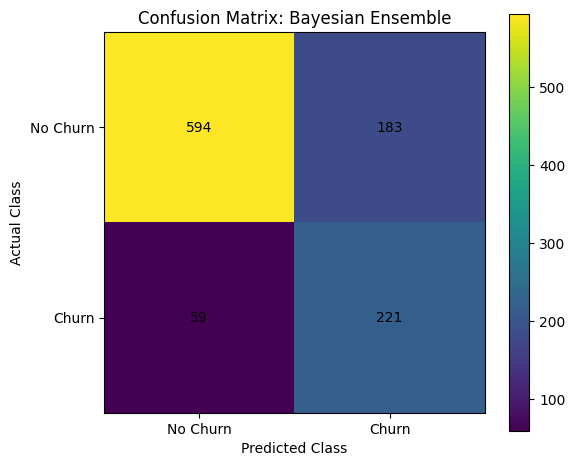

In [107]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

matrix_image = ax.imshow(
    final_confusion_matrix
)

ax.set_title(
    f"Confusion Matrix: {best_test_model_name}"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks(
    [0, 1],
    labels=[
        "No Churn",
        "Churn"
    ]
)

ax.set_yticks(
    [0, 1],
    labels=[
        "No Churn",
        "Churn"
    ]
)

for row in range(2):
    for column in range(2):
        ax.text(
            column,
            row,
            final_confusion_matrix[
                row,
                column
            ],
            ha="center",
            va="center"
        )

fig.colorbar(
    matrix_image,
    ax=ax
)

plt.tight_layout()

plt.savefig(
    "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
from sklearn.metrics import RocCurveDisplay

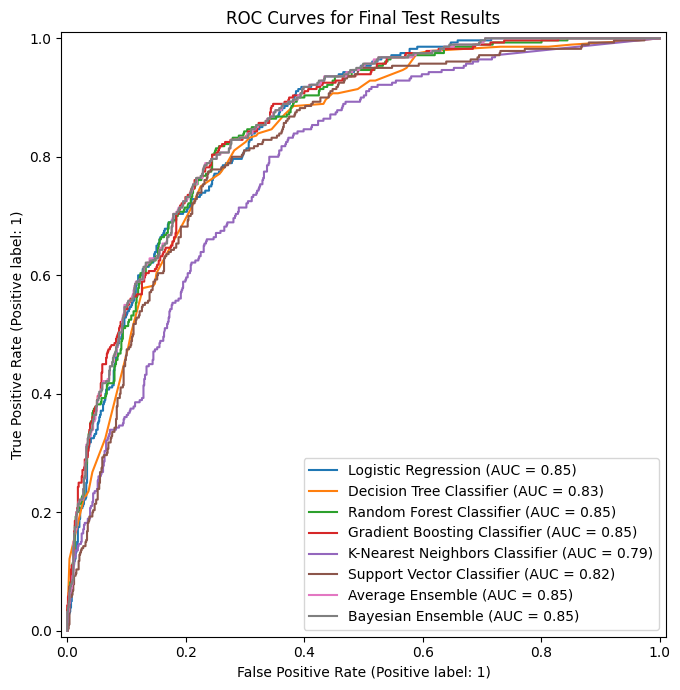

In [109]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

for model_name, probabilities in (
    test_probability_dictionary.items()
):

    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=ax
    )

RocCurveDisplay.from_predictions(
    y_test,
    average_test_probabilities,
    name="Average Ensemble",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    bayesian_test_probabilities,
    name="Bayesian Ensemble",
    ax=ax
)

ax.set_title(
    "ROC Curves for Final Test Results"
)

plt.tight_layout()

plt.savefig(
    "final_test_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
average_test_results = evaluate_model(
    model_name="Average Ensemble",
    actual_values=y_test,
    predicted_values=average_test_predictions,
    predicted_probabilities=average_test_probabilities
)

# Prevent duplicates if this cell is run more than once
test_results = [
    result for result in test_results
    if result["Model"] != "Average Ensemble"
]

test_results.append(average_test_results)

average_test_results

{'Model': 'Average Ensemble',
 'Accuracy': 0.7587511825922422,
 'Precision': 0.5292740046838408,
 'Recall': 0.8071428571428572,
 'F1-Score': 0.6393210749646393,
 'ROC-AUC': np.float64(0.852893454679169)}

In [111]:
validation_comparison = validation_results_df.copy()
validation_comparison["Split"] = "Validation"

test_comparison = test_results_df.copy()
test_comparison["Split"] = "Test"

complete_model_comparison = pd.concat(
    [
        validation_comparison,
        test_comparison
    ],
    ignore_index=True
)

complete_model_comparison = complete_model_comparison[
    [
        "Model",
        "Split",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

display(complete_model_comparison.round(4))

,Model,Split,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting Classifier,Validation,0.7616,0.5351,0.7865,0.6369,0.8376
1,Bayesian Ensemble,Validation,0.7701,0.5503,0.7402,0.6313,0.8374
2,Average Ensemble,Validation,0.7569,0.5302,0.7509,0.6215,0.8373
3,Random Forest Classifier,Validation,0.7616,0.5381,0.7295,0.6193,0.8329
4,Logistic Regression,Validation,0.7531,0.5237,0.7865,0.6287,0.8319
5,Decision Tree Classifier,Validation,0.7408,0.5085,0.7473,0.6052,0.8144
6,Decision Tree Classifier,Validation,0.7408,0.5085,0.7473,0.6052,0.8144
7,Support Vector Classifier,Validation,0.7417,0.5097,0.7473,0.6061,0.8069
8,K-Nearest Neighbors Classifier,Validation,0.6859,0.4452,0.7367,0.5550,0.7769
9,Bayesian Ensemble,Test,0.7711,0.5470,0.7893,0.6462,0.8531


## Final Model Evaluation

The models were first compared using the validation dataset. The three strongest individual models were combined using an Average Ensemble and a Bayesian Ensemble. After model development was completed, all models were evaluated on the untouched test dataset.

The Bayesian Ensemble produced the highest test ROC-AUC score of **0.8531**. It achieved an accuracy of **0.7711**, precision of **0.5470**, recall of **0.7893**, and an F1-score of **0.6462**. These results show that the Bayesian Ensemble was able to correctly rank customers according to their likelihood of churn while identifying approximately 79% of the customers who actually churned.

Recall is especially important for this customer-churn problem because a false negative represents a customer who is likely to leave but is not identified by the company. The final confusion matrix showed that the Bayesian Ensemble correctly identified 221 customers who churned and missed 59 customers who churned. It also correctly identified 594 customers who did not churn but incorrectly classified 183 non-churning customers as likely to churn.

The Bayesian Ensemble slightly outperformed the individual models by learning how to combine the predictions of the three strongest models. Gradient Boosting was the strongest individual validation model, while K-Nearest Neighbors produced the weakest overall results. The findings demonstrate that combining several machine-learning models can improve customer-churn predictions.
